Nama : Untara Eka Saputra

NIM :3.34.23.3.24

Kelas : IK - 3D

# **Praktikum 1. Menghitung Jarak Berbasis Piksel (Euclidean & Manhattan)**

Jarak Euclidean Patch1-Patch2: 24.7650
Jarak Euclidean Patch1-Patch3: 5.0000
Jarak Manhattan Patch1-Patch2: 936.4392
Jarak Manhattan Patch1-Patch3: 250.0000


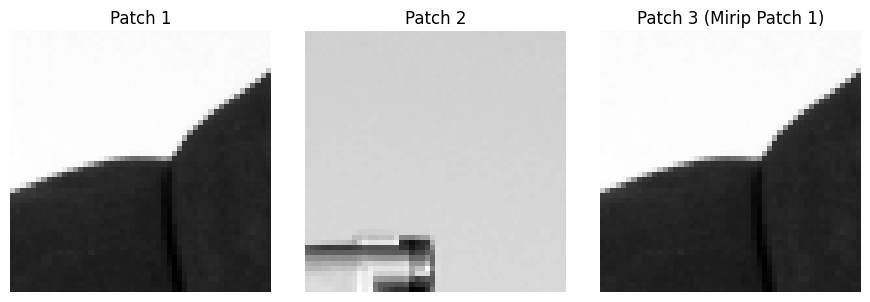

In [2]:
import numpy as np
from skimage import data, img_as_float
from scipy.spatial import distance
import matplotlib.pyplot as plt

# 1. Ambil citra
image = img_as_float(data.camera())

# 2. Membuat patch
patch1 = image[100:150, 100:150]
patch2 = image[100:150, 300:350]
patch3 = patch1 + 0.1
patch3 = np.clip(patch3, 0, 1)

# 3. Ubah menjadi vektor 1D
vec1 = patch1.flatten()
vec2 = patch2.flatten()
vec3 = patch3.flatten()

# 4. Hitung jarak Euclidean (L2)
dist_l2_12 = distance.euclidean(vec1, vec2)
dist_l2_13 = distance.euclidean(vec1, vec3)

# 5. Hitung jarak Manhattan (L1)
dist_l1_12 = distance.cityblock(vec1, vec2)
dist_l1_13 = distance.cityblock(vec1, vec3)

# 6. Tampilkan hasil
print(f"Jarak Euclidean Patch1-Patch2: {dist_l2_12:.4f}")
print(f"Jarak Euclidean Patch1-Patch3: {dist_l2_13:.4f}")

print(f"Jarak Manhattan Patch1-Patch2: {dist_l1_12:.4f}")
print(f"Jarak Manhattan Patch1-Patch3: {dist_l1_13:.4f}")

# 7. Visualisasi
fig, axes = plt.subplots(1, 3, figsize=(9,3))

axes[0].imshow(patch1, cmap='gray')
axes[0].set_title('Patch 1')
axes[0].axis('off')

axes[1].imshow(patch2, cmap='gray')
axes[1].set_title('Patch 2')
axes[1].axis('off')

axes[2].imshow(patch3, cmap='gray')
axes[2].set_title('Patch 3 (Mirip Patch 1)')
axes[2].axis('off')

plt.tight_layout()
plt.show()

# **Praktikum 2. Menghitung Cosine Similarity antara Histogram Warna**

Cosine Similarity Image 1 vs Image 2 : 0.8156
Cosine Similarity Image 1 vs Image 3 : 1.0000
Cosine Similarity Image 1 vs Image 4 : 1.0000


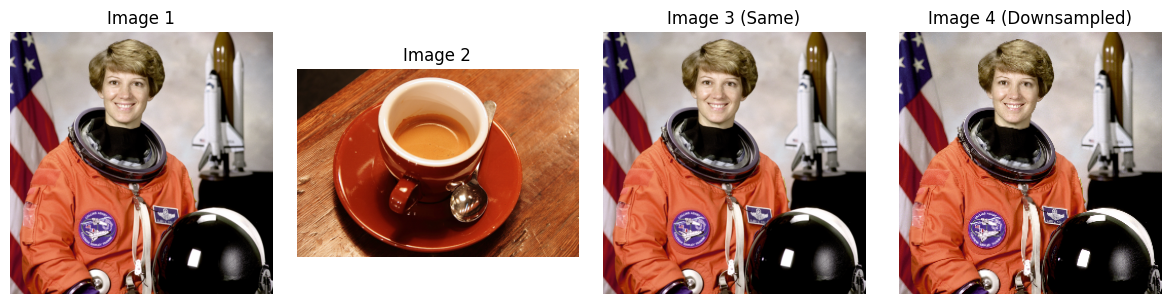

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_ubyte
from scipy.spatial import distance

# Fungsi untuk menghitung histogram RGB gabungan
def calculate_rgb_histogram(image, bins=16):
    img_uint8 = img_as_ubyte(image)

    hist_r, _ = np.histogram(
        img_uint8[:, :, 0].ravel(),
        bins=bins,
        range=(0, 256)
    )

    hist_g, _ = np.histogram(
        img_uint8[:, :, 1].ravel(),
        bins=bins,
        range=(0, 256)
    )

    hist_b, _ = np.histogram(
        img_uint8[:, :, 2].ravel(),
        bins=bins,
        range=(0, 256)
    )

    # Gabungkan histogram R, G, dan B
    hist_combined = np.concatenate((hist_r, hist_g, hist_b))

    # Normalisasi histogram
    hist_combined = hist_combined.astype(float) / np.sum(hist_combined)

    return hist_combined


# 1. Muat dua citra berwarna
try:
    # Menggunakan citra bawaan skimage
    image1 = data.astronaut()
    image2 = data.coffee()          # Citra berbeda
    image3 = data.astronaut()       # Citra sama
    image4 = image1[::2, ::2, :]    # Downsampled image

except Exception as e:
    print(f"Gagal memuat data skimage: {e}")

    # Membuat citra dummy jika gagal
    image1 = np.random.rand(100, 100, 3)
    image2 = np.random.rand(100, 100, 3) * 0.5
    image3 = image1.copy()
    image4 = image1[::2, ::2, :]


# 2. Hitung histogram tiap citra
hist1 = calculate_rgb_histogram(image1)
hist2 = calculate_rgb_histogram(image2)
hist3 = calculate_rgb_histogram(image3)
hist4 = calculate_rgb_histogram(image4)


# 3. Hitung Cosine Similarity
# distance.cosine menghasilkan cosine distance
# Similarity = 1 - cosine distance

sim_12 = 1 - distance.cosine(hist1, hist2)
sim_13 = 1 - distance.cosine(hist1, hist3)
sim_14 = 1 - distance.cosine(hist1, hist4)


# 4. Tampilkan hasil
print(f"Cosine Similarity Image 1 vs Image 2 : {sim_12:.4f}")
print(f"Cosine Similarity Image 1 vs Image 3 : {sim_13:.4f}")
print(f"Cosine Similarity Image 1 vs Image 4 : {sim_14:.4f}")


# 5. Visualisasi gambar
fig, axes = plt.subplots(1, 4, figsize=(12, 3))

axes[0].imshow(image1)
axes[0].set_title("Image 1")
axes[0].axis("off")

axes[1].imshow(image2)
axes[1].set_title("Image 2")
axes[1].axis("off")

axes[2].imshow(image3)
axes[2].set_title("Image 3 (Same)")
axes[2].axis("off")

axes[3].imshow(image4)
axes[3].set_title("Image 4 (Downsampled)")
axes[3].axis("off")

plt.tight_layout()
plt.show()

# **Praktikum 3. Menghitung Structural Similarity Index (SSIM)**

SSIM (Ref vs Same)     : 1.0000
SSIM (Ref vs Noisy)    : 0.2957
SSIM (Ref vs Contrast) : 0.9651
SSIM (Ref vs Blurred)  : 0.8027


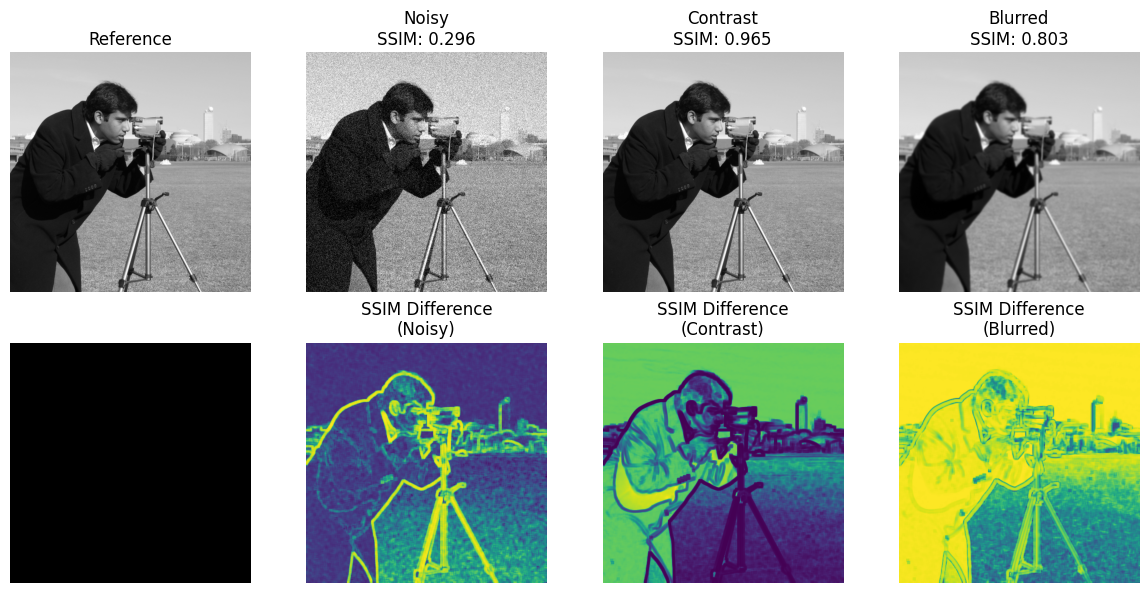

In [6]:
import numpy as np
import matplotlib.pyplot as plt

from skimage import data, img_as_float
from skimage.metrics import structural_similarity as ssim
from skimage.util import random_noise
from skimage.filters import gaussian


# 1. Muat citra referensi
image_ref = img_as_float(data.camera())


# 2. Buat beberapa versi citra yang "terdistorsi"

# a) Citra yang sama
image_same = image_ref.copy()

# b) Citra dengan noise Gaussian
image_noisy = random_noise(
    image_ref,
    mode='gaussian',
    var=0.01
)

# c) Citra dengan kontras berbeda
image_contrast = np.clip(image_ref * 0.8, 0, 1)

# d) Citra blur
image_blurred = gaussian(
    image_ref,
    sigma=1.5,
    channel_axis=None   # Karena grayscale
)


# 3. Hitung SSIM
# SSIM membutuhkan data_range

data_range = image_ref.max() - image_ref.min()

ssim_same, _ = ssim(
    image_ref,
    image_same,
    data_range=data_range,
    full=True
)

ssim_noisy, diff_noisy = ssim(
    image_ref,
    image_noisy,
    data_range=data_range,
    full=True
)

ssim_contrast, diff_contrast = ssim(
    image_ref,
    image_contrast,
    data_range=data_range,
    full=True
)

ssim_blurred, diff_blurred = ssim(
    image_ref,
    image_blurred,
    data_range=data_range,
    full=True
)

# full=True akan mengembalikan citra perbedaan SSIM juga


# 4. Tampilkan hasil
print(f"SSIM (Ref vs Same)     : {ssim_same:.4f}")
print(f"SSIM (Ref vs Noisy)    : {ssim_noisy:.4f}")
print(f"SSIM (Ref vs Contrast) : {ssim_contrast:.4f}")
print(f"SSIM (Ref vs Blurred)  : {ssim_blurred:.4f}")


# 5. Visualisasi hasil
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
ax = axes.ravel()


# Baris pertama → citra hasil
ax[0].imshow(image_ref, cmap='gray')
ax[0].set_title("Reference")
ax[0].axis("off")

ax[1].imshow(image_noisy, cmap='gray')
ax[1].set_title(f"Noisy\nSSIM: {ssim_noisy:.3f}")
ax[1].axis("off")

ax[2].imshow(image_contrast, cmap='gray')
ax[2].set_title(f"Contrast\nSSIM: {ssim_contrast:.3f}")
ax[2].axis("off")

ax[3].imshow(image_blurred, cmap='gray')
ax[3].set_title(f"Blurred\nSSIM: {ssim_blurred:.3f}")
ax[3].axis("off")


# Baris kedua → peta perbedaan SSIM
ax[4].imshow(np.zeros_like(image_ref), cmap='gray')
ax[4].set_title("")
ax[4].axis("off")   # Placeholder kosong

ax[5].imshow(diff_noisy, cmap='viridis')
ax[5].set_title("SSIM Difference\n(Noisy)")
ax[5].axis("off")

ax[6].imshow(diff_contrast, cmap='viridis')
ax[6].set_title("SSIM Difference\n(Contrast)")
ax[6].axis("off")

ax[7].imshow(diff_blurred, cmap='viridis')
ax[7].set_title("SSIM Difference\n(Blurred)")
ax[7].axis("off")


plt.tight_layout()
plt.show()

# **Praktikum 4. Penerapan Template Matching**

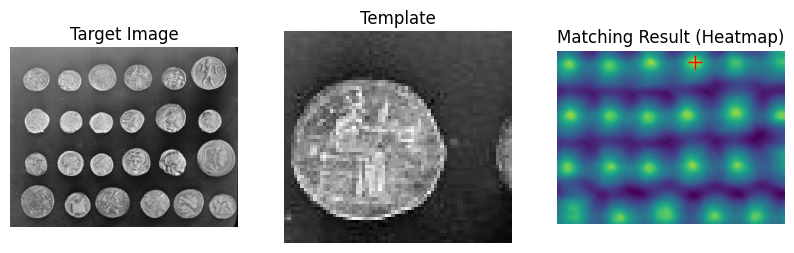

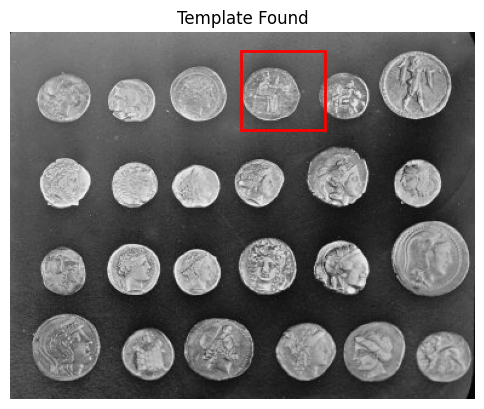

Template ditemukan di koordinat (x, y): (190, 15)


In [7]:
import numpy as np
import matplotlib.pyplot as plt

from skimage import data
from skimage.feature import match_template


# 1. Muat citra target dan template
image = data.coins()

# Ambil salah satu bagian koin sebagai template
template = image[15:80, 190:260]


# 2. Template Matching menggunakan
# Normalized Cross-Correlation
result = match_template(image, template)


# 3. Cari lokasi dengan skor matching tertinggi
# np.argmax -> indeks nilai terbesar
# unravel_index -> ubah ke koordinat 2D

ij = np.unravel_index(np.argmax(result), result.shape)

# Koordinat sudut kiri atas
x, y = ij[::-1]


# 4. Visualisasi hasil
fig, ax = plt.subplots(1, 3, figsize=(10, 4))


# Citra target
ax[0].imshow(image, cmap='gray')
ax[0].set_title("Target Image")
ax[0].set_axis_off()


# Template
ax[1].imshow(template, cmap='gray')
ax[1].set_title("Template")
ax[1].set_axis_off()


# Heatmap hasil matching
ax[2].imshow(result, cmap='viridis')
ax[2].set_title("Matching Result (Heatmap)")
ax[2].set_axis_off()

# Tandai lokasi terbaik pada heatmap
ax[2].plot(x, y, 'r+', markersize=10)


# 5. Tampilkan lokasi template pada citra asli
fig2, ax_main = plt.subplots(figsize=(6, 6))

ax_main.imshow(image, cmap='gray')
ax_main.set_title("Template Found")
ax_main.set_axis_off()


# Ukuran template
h, w = template.shape

# Kotak penanda lokasi template
rect = plt.Rectangle(
    (x, y),
    w,
    h,
    edgecolor='r',
    facecolor='none',
    lw=2
)

ax_main.add_patch(rect)


# Tampilkan semua plot
plt.show()


# 6. Cetak koordinat hasil matching
print(f"Template ditemukan di koordinat (x, y): ({x}, {y})")

# **Praktikum 5. Simulasi Content-Based Image Retrieval (CBIR) Sederhana**

Memproses database citra...
- astronaut diproses.
- camera diproses.
- coffee diproses.
- coins diproses.
- chelsea diproses.

Hasil Retrieval:
(Semakin kecil distance → semakin mirip)

Rank 1: chelsea (Distance: 0.000)
Rank 2: coins (Distance: 0.288)
Rank 3: coffee (Distance: 0.359)
Rank 4: astronaut (Distance: 0.461)
Rank 5: camera (Distance: 0.602)


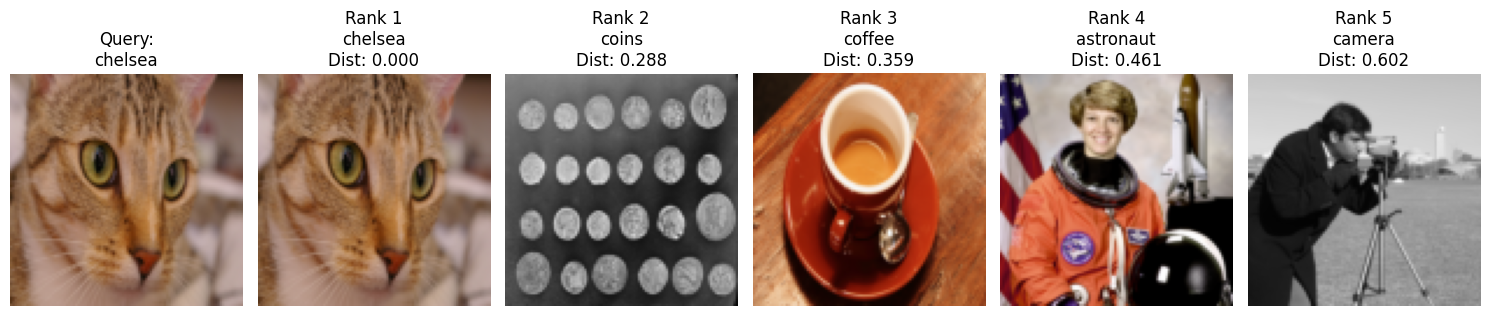

In [8]:
import numpy as np
import matplotlib.pyplot as plt

from skimage import (
    data,
    color,
    transform,
    img_as_ubyte
)

from scipy.spatial import distance


# Fungsi menghitung histogram RGB
def calculate_rgb_histogram(image, bins=16):

    # Jika citra float [0,1], ubah ke uint8 [0,255]
    if image.dtype == float:
        image = img_as_ubyte(image)

    # Histogram channel R
    hist_r, _ = np.histogram(
        image[:, :, 0].ravel(),
        bins=bins,
        range=(0, 256)
    )

    # Histogram channel G
    hist_g, _ = np.histogram(
        image[:, :, 1].ravel(),
        bins=bins,
        range=(0, 256)
    )

    # Histogram channel B
    hist_b, _ = np.histogram(
        image[:, :, 2].ravel(),
        bins=bins,
        range=(0, 256)
    )

    # Gabungkan histogram RGB
    hist_combined = np.concatenate((hist_r, hist_g, hist_b))

    # Normalisasi L1 (jumlah total = 1)
    hist_sum = np.sum(hist_combined)

    if hist_sum > 0:
        hist_combined = hist_combined.astype(float) / hist_sum
    else:
        # Hindari division by zero
        hist_combined = hist_combined.astype(float)

    return hist_combined


# 1. Siapkan database citra
image_db_names = [
    "astronaut",
    "camera",
    "coffee",
    "coins",
    "chelsea"
]

database_images = []
database_hists = []

print("Memproses database citra...")


for name in image_db_names:

    try:
        # Ambil gambar dari skimage.data
        img = getattr(data, name)()

        # Jika grayscale → ubah ke RGB
        if img.ndim == 2:
            img = color.gray2rgb(img)

        # Resize agar ukuran konsisten
        img_resized = transform.resize(
            img,
            (100, 100),
            anti_aliasing=True
        )

        # Simpan gambar
        database_images.append(img_resized)

        # Hitung histogram
        database_hists.append(
            calculate_rgb_histogram(img_resized)
        )

        print(f"- {name} diproses.")

    except Exception as e:
        print(f"Error memproses {name}: {e}")


# 2. Pilih query image
query_image_name = "chelsea"

query_index = image_db_names.index(query_image_name)

query_image = database_images[query_index]
query_hist = database_hists[query_index]


# 3. Hitung jarak cosine distance
distances = []

for hist in database_hists:

    # Cosine Distance
    dist = distance.cosine(query_hist, hist)

    distances.append(dist)


# 4. Urutkan berdasarkan jarak terkecil
sorted_indices = np.argsort(distances)


# 5. Visualisasi hasil retrieval
num_results_to_show = len(database_images)

fig, axes = plt.subplots(
    1,
    num_results_to_show + 1,
    figsize=(15, 3)
)


# Tampilkan query image
axes[0].imshow(query_image)

axes[0].set_title(
    f"Query:\n{query_image_name}"
)

axes[0].axis("off")


# Tampilkan hasil retrieval
print("\nHasil Retrieval:")
print("(Semakin kecil distance → semakin mirip)\n")


for i, idx in enumerate(sorted_indices):

    rank = i + 1

    ax = axes[rank]

    ax.imshow(database_images[idx])

    ax.set_title(
        f"Rank {rank}\n"
        f"{image_db_names[idx]}\n"
        f"Dist: {distances[idx]:.3f}"
    )

    ax.axis("off")

    print(
        f"Rank {rank}: "
        f"{image_db_names[idx]} "
        f"(Distance: {distances[idx]:.3f})"
    )


# Matikan axis kosong jika ada
for j in range(num_results_to_show + 1, len(axes)):
    axes[j].axis("off")


plt.tight_layout()
plt.show()

# **3.	Fitur Berbeda untuk CBIR**

Memproses database citra...
- astronaut diproses.
- camera diproses.
- coffee diproses.
- coins diproses.
- chelsea diproses.

Hasil Retrieval:
(Semakin kecil distance → semakin mirip)

Rank 1: chelsea (Distance: 0.000)
Rank 2: astronaut (Distance: 0.050)
Rank 3: coffee (Distance: 0.176)
Rank 4: camera (Distance: 0.194)
Rank 5: coins (Distance: 0.211)


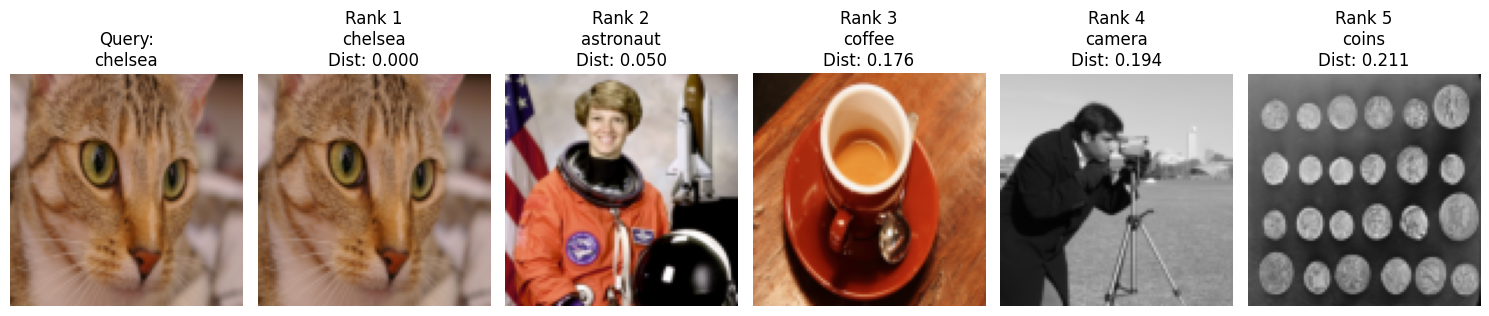

In [9]:
import numpy as np
import matplotlib.pyplot as plt

from skimage import (
    data,
    color,
    transform
)

from scipy.spatial import distance


# =========================================================
# Fungsi menghitung fitur rata-rata warna RGB
# =========================================================
def calculate_mean_rgb(image):

    # Mean channel Red
    mean_r = np.mean(image[:, :, 0])

    # Mean channel Green
    mean_g = np.mean(image[:, :, 1])

    # Mean channel Blue
    mean_b = np.mean(image[:, :, 2])

    # Gabungkan menjadi vektor fitur
    feature_vector = np.array([
        mean_r,
        mean_g,
        mean_b
    ])

    return feature_vector


# =========================================================
# 1. Siapkan database citra
# =========================================================
image_db_names = [
    "astronaut",
    "camera",
    "coffee",
    "coins",
    "chelsea"
]

database_images = []
database_features = []

print("Memproses database citra...")


for name in image_db_names:

    try:
        # Ambil gambar dari skimage.data
        img = getattr(data, name)()

        # Jika grayscale → ubah ke RGB
        if img.ndim == 2:
            img = color.gray2rgb(img)

        # Resize agar ukuran konsisten
        img_resized = transform.resize(
            img,
            (100, 100),
            anti_aliasing=True
        )

        # Simpan gambar
        database_images.append(img_resized)

        # Hitung fitur mean RGB
        feature = calculate_mean_rgb(img_resized)

        database_features.append(feature)

        print(f"- {name} diproses.")

    except Exception as e:
        print(f"Error memproses {name}: {e}")


# =========================================================
# 2. Pilih query image
# =========================================================
query_image_name = "chelsea"

query_index = image_db_names.index(query_image_name)

query_image = database_images[query_index]

query_feature = database_features[query_index]


# =========================================================
# 3. Hitung jarak Euclidean
# =========================================================
distances = []

for feature in database_features:

    # Euclidean Distance (L2)
    dist = distance.euclidean(
        query_feature,
        feature
    )

    distances.append(dist)


# =========================================================
# 4. Urutkan berdasarkan jarak terkecil
# =========================================================
sorted_indices = np.argsort(distances)


# =========================================================
# 5. Visualisasi hasil retrieval
# =========================================================
num_results_to_show = len(database_images)

fig, axes = plt.subplots(
    1,
    num_results_to_show + 1,
    figsize=(15, 3)
)


# Tampilkan query image
axes[0].imshow(query_image)

axes[0].set_title(
    f"Query:\n{query_image_name}"
)

axes[0].axis("off")


# Tampilkan hasil retrieval
print("\nHasil Retrieval:")
print("(Semakin kecil distance → semakin mirip)\n")


for i, idx in enumerate(sorted_indices):

    rank = i + 1

    ax = axes[rank]

    ax.imshow(database_images[idx])

    ax.set_title(
        f"Rank {rank}\n"
        f"{image_db_names[idx]}\n"
        f"Dist: {distances[idx]:.3f}"
    )

    ax.axis("off")

    print(
        f"Rank {rank}: "
        f"{image_db_names[idx]} "
        f"(Distance: {distances[idx]:.3f})"
    )


plt.tight_layout()
plt.show()

## **4. Template Matching Invariant**

=== HASIL TEMPLATE MATCHING ===

Original Template Score : 1.0000
Rotated Template Score  : 0.6059
Scaled Template Score   : 0.5922


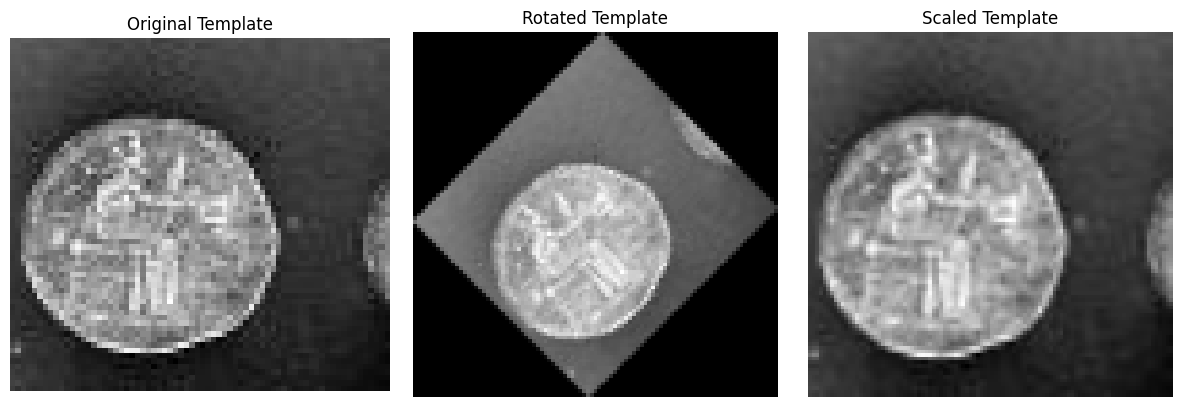

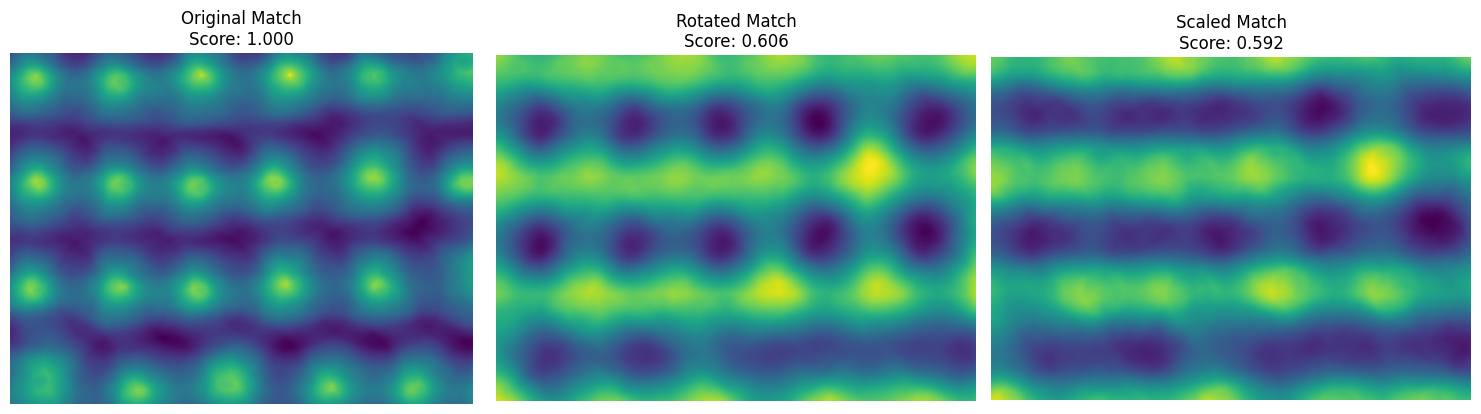


=== KESIMPULAN ===
Metode match_template() tidak invariant terhadap rotasi dan perubahan skala.
Hal ini terlihat dari skor matching template rotasi dan skala yang menurun dibanding template asli.


In [10]:
import numpy as np
import matplotlib.pyplot as plt

from skimage import data
from skimage.feature import match_template
from skimage.transform import rotate, resize


# =========================================================
# 1. Muat citra target dan template asli
# =========================================================
image = data.coins()

# Ambil salah satu bagian koin sebagai template
template = image[15:80, 190:260]


# =========================================================
# 2. Buat template hasil rotasi dan perubahan skala
# =========================================================

# Template diputar 45 derajat
template_rotated = rotate(
    template,
    angle=45,
    resize=True
)

# Template diperbesar
template_scaled = resize(
    template,
    (100, 100)
)


# =========================================================
# 3. Lakukan template matching
# =========================================================

# Matching template asli
result_original = match_template(
    image,
    template
)

# Matching template rotasi
result_rotated = match_template(
    image,
    template_rotated
)

# Matching template skala
result_scaled = match_template(
    image,
    template_scaled
)


# =========================================================
# 4. Cari lokasi matching terbaik
# =========================================================

# Template asli
ij_original = np.unravel_index(
    np.argmax(result_original),
    result_original.shape
)

x_original, y_original = ij_original[::-1]


# Template rotasi
ij_rotated = np.unravel_index(
    np.argmax(result_rotated),
    result_rotated.shape
)

x_rotated, y_rotated = ij_rotated[::-1]


# Template skala
ij_scaled = np.unravel_index(
    np.argmax(result_scaled),
    result_scaled.shape
)

x_scaled, y_scaled = ij_scaled[::-1]


# =========================================================
# 5. Hitung skor maksimum matching
# =========================================================

score_original = np.max(result_original)
score_rotated = np.max(result_rotated)
score_scaled = np.max(result_scaled)


# =========================================================
# 6. Tampilkan skor hasil matching
# =========================================================

print("=== HASIL TEMPLATE MATCHING ===\n")

print(f"Original Template Score : {score_original:.4f}")
print(f"Rotated Template Score  : {score_rotated:.4f}")
print(f"Scaled Template Score   : {score_scaled:.4f}")


# =========================================================
# 7. Visualisasi template
# =========================================================

fig, ax = plt.subplots(1, 3, figsize=(12, 4))


# Template asli
ax[0].imshow(template, cmap='gray')
ax[0].set_title("Original Template")
ax[0].axis("off")


# Template rotasi
ax[1].imshow(template_rotated, cmap='gray')
ax[1].set_title("Rotated Template")
ax[1].axis("off")


# Template skala
ax[2].imshow(template_scaled, cmap='gray')
ax[2].set_title("Scaled Template")
ax[2].axis("off")


plt.tight_layout()
plt.show()


# =========================================================
# 8. Visualisasi heatmap hasil matching
# =========================================================

fig2, ax2 = plt.subplots(1, 3, figsize=(15, 4))


# Heatmap original
ax2[0].imshow(result_original, cmap='viridis')
ax2[0].set_title(
    f"Original Match\nScore: {score_original:.3f}"
)
ax2[0].axis("off")


# Heatmap rotated
ax2[1].imshow(result_rotated, cmap='viridis')
ax2[1].set_title(
    f"Rotated Match\nScore: {score_rotated:.3f}"
)
ax2[1].axis("off")


# Heatmap scaled
ax2[2].imshow(result_scaled, cmap='viridis')
ax2[2].set_title(
    f"Scaled Match\nScore: {score_scaled:.3f}"
)
ax2[2].axis("off")


plt.tight_layout()
plt.show()


# =========================================================
# 9. Kesimpulan otomatis
# =========================================================

print("\n=== KESIMPULAN ===")

print(
    "Metode match_template() tidak invariant "
    "terhadap rotasi dan perubahan skala."
)

print(
    "Hal ini terlihat dari skor matching template "
    "rotasi dan skala yang menurun dibanding template asli."
)